In [29]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

filename = 'side_output.csv'
df = pd.read_csv(filename, header=None,index_col=0).T

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

总数:4104
夹零比例:1.584%
总数>=75比例:9.966%
半场>=36比例:65.278%
全红比例:0.000%


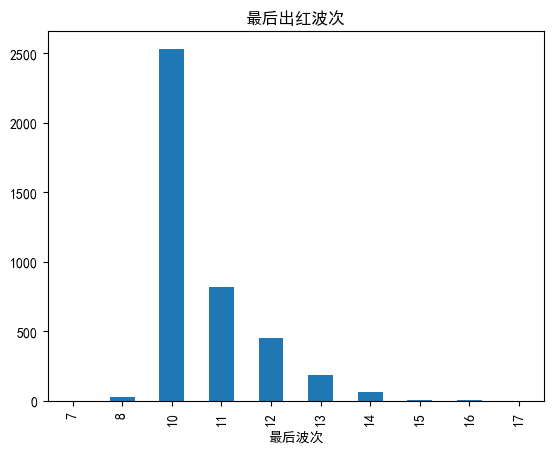

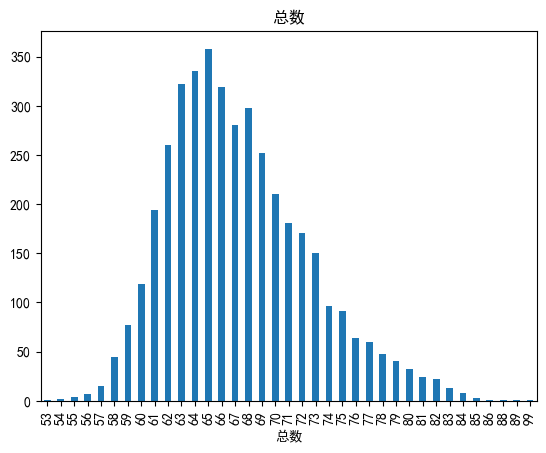

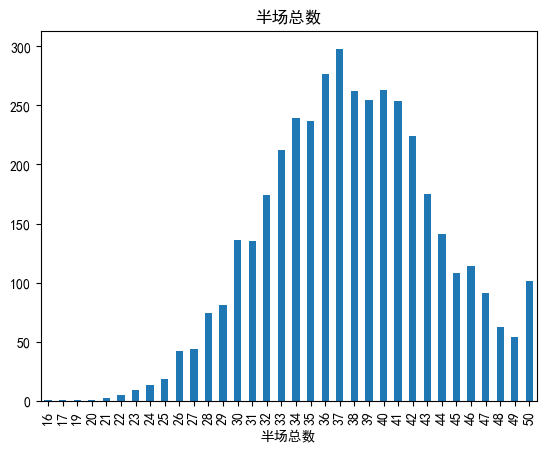

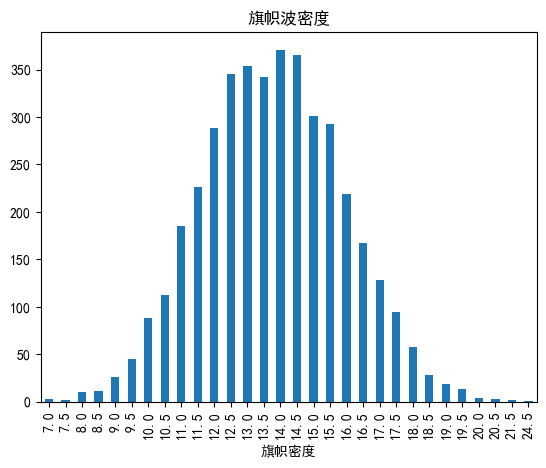

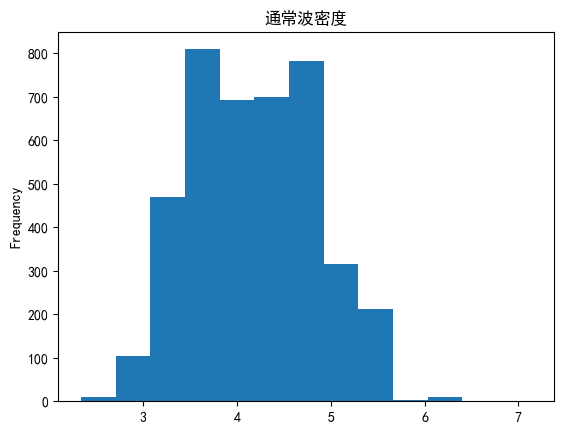

In [30]:
# 红眼
# # print(df)
df['普通总数']=df['总数']-df['旗帜总数']
df['旗帜密度']=1.0*df['旗帜总数']/2
df['普通波次']=df['最后波次']-1
for index, row in df.iterrows():
    if row['最后波次'] <= 9:
        df.at[index, '普通波次'] = row['普通波次'] + 1
df['普通密度']=1.0*(df['总数']-df['旗帜总数'])/df['普通波次']

# print(df)
print(f'总数:{len(df)}')

value_counts = df['不夹零'].value_counts()
print(f'夹零比例:{100.0*value_counts[0]/(value_counts[0]+value_counts[1]):.3f}%')

cl = 75
half_cl = 36
print(f'总数>={cl}比例:{100.0*len(df[df['总数']>=cl])/len(df):.3f}%')
print(f'半场>={half_cl}比例:{100.0*len(df[df['半场总数']>=half_cl])/len(df):.3f}%')

print(f'全红比例:{100.0*len(df[df['最后波次']==19])/len(df):.3f}%')

value_counts = df['最后波次'].value_counts().sort_index()  
value_counts.plot(kind='bar')
plt.title('最后出红波次')
plt.show()

value_counts = df['总数'].value_counts().sort_index()  
value_counts.plot(kind='bar')
plt.title('总数')
plt.show()

value_counts = df['半场总数'].value_counts().sort_index()  
value_counts.plot(kind='bar')
plt.title('半场总数')
plt.show()

value_counts = df['旗帜密度'].value_counts().sort_index()  
value_counts.plot(kind='bar')
plt.title('旗帜波密度')
plt.show()

df['普通密度'].plot(kind='hist', bins=int(math.log(len(df),2)+1))  
plt.title('通常波密度')
plt.show()